# Calculation and plotting of GRUAN Reference Upper-Air radiosonde measurements

This notebook-tutorial provides a practical introduction to the CDS dataset named **[In situ temperature, relative humidity and wind profiles from the GRUAN reference network]**.

The present notebook analyses atmospheric thermodynamic and kinematic observations collected within the **GCOS Reference Upper-Air Network (GRUAN)** [1]. The notebook demonstrates methods for exploring and visualising GRUAN reference radiosonde observations and measurement uncertainty through graphical diagnostics and plots.

This notebook provides a practical introduction to GRUAN upper-air observations distributed through the Copernicus Climate Data Store (CDS). It demonstrates how to load, process, analyse, and visualise vertically resolved temperature, humidity, and wind observations collected across the GRUAN network.

Three complementary use cases are presented:
1. **Plots of the mean profile of vertical upper-air profiles** with the related propagated measurement uncertainty;
2. **Investigation time–height atmospheric variability** through cross-sectional visualisations;
3. **Statistical characterisation of key upper-air variables** through altitude-binned distribution and variability analyses.

All of these cases can be executed under two options: either for a single GRUAN station or for all stations available within a bounding box.

The notebook includes step-by-step instructions covering data loading, spatial selection (station vs. bounding box), temporal aggregation, uncertainty propagation, and visualisation procedures. Each analysis module is accompanied by detailed documentation explaining the methodology, the underlying atmospheric interpretation, and the corresponding code implementation.



## 1. Introduction

The*GCOS Reference Upper-Air Network (GRUAN) is an international reference observing network designed to provide long-term, high-quality climate data records from the surface into the stratosphere. Coordinated jointly by the World Meteorological Organization (WMO) and the Global Climate Observing System (GCOS), GRUAN provides a standardized framework for the collection, metrological calibration, processing, and dissemination of vertically resolved atmospheric profiles. Observations are obtained using state-of-the-art upper-air instruments, primarily high-precision radiosondes (such as Vaisala RS92 [2] and RS41 [3] or Meisei IMS-100 [4] and RS11-G [5], alongside cryogenic frost-point hygrometers, GNSS for precipitable water vapour, lidars, and microwave radiometers). The network plays a fundamental role in climate change detection, satellite sensor calibration and validation (Cal/Val), numerical weather prediction (NWP) model evaluation, and the assessment of atmospheric reanalyses (e.g., ERA5).

The radiosonde component of GRUAN provides continuous, high-vertical-resolution measurements of key atmospheric variables from ground level up to ~30-35 km altitude. Unlike routine operational observations, GRUAN processing explicitly prioritises metrological traceability to SI units, rigorous quantification of measurement uncertainties at every vertical level, and the complete documentation of raw data and metadata. This reference approach ensures that subtle long-term climate signals and boundary-layer-to-stratosphere transitions can be detected without contamination from instrument changes or uncalibrated sensor drift.

Within the framework of the Copernicus Climate Change Service (C3S), GRUAN upper-air observations are processed to ensure that all variables and data structures are fully compliant with the C3S Common Data Model for Observational Data (CDM-OBS). These harmonised datasets provide seamless access to the GRUAN upper-air data records, enabling users to explore atmospheric vertical structure and variability across local, regional, and global scales.

The GRUAN CDS dataset focuses on core thermodynamic and kinematic state variables alongside their explicit observation uncertainties. Available variables include:
* Air temperature (e.g., CDM-OBS code `126` in the "observed_variable" table)
* Relative humidity (e.g., variable code `138`)
* Wind speed** (e.g., variable code `107`) and wind direction
* Geopotential altitude (`z_coordinate`) and pressure

Each observation value is coupled with a dedicated measurement uncertainty estimate (`uncertainty_value1`), which accounts for both random and correlated uncertainty contributions due to the sensor response time, solar radiation heating, calibration, etc.

To preserve scientific integrity, GRUAN data products undergo rigorous pre-processing and quality-control protocols. 

This notebook provides a practical tutorial for working with GRUAN upper-air profile datasets available in the CDS. It demonstrates how to load, filter, aggregate, and visualize high-resolution profile data.

## 2. Prerequisites and data preparation
This chapter describes the software environment, library dependencies, and data preparation steps required to execute the analysis workflows presented in this notebook.

### 2.1 How to access and run the notebook
This tutorial is structured as an interactive Jupyter Notebook and can be executed either locally or in cloud-based Python environments (e.g., JupyterLab, Anaconda, or Binder).

For local execution, users should ensure that a Python 3.9+ environment is installed along with the scientific computing packages listed below.

### 2.2 Required python libraries
The analyses and visualisations rely on standard scientific Python modules for multidimensional data handling, vectorised mathematical calculations, statistical aggregation, and plotting.

The required packages are:
* **`numpy`**: vectorised numerical operations, array manipulation, and statistical binning;
* **`pandas`**: tabular data handling, date-time indexing, and series processing;
* **`xarray`** & **`netCDF4`**: multidimensional NetCDF data ingestion and Common Data Model (CDM) variable indexing;
* **`scipy`**: scientific utilities, spatial binning, and signal filtering;
* **`matplotlib`**: primary scientific visualisations and multi-panel profile plotting;
* **`seaborn`**: statistical plotting enhancement and palette handling;
* **`warnings`** & **`os`**: runtime environment control and file path management.

You can install all dependencies via `pip`:

```bash
pip install numpy pandas xarray netcdf4 scipy matplotlib seaborn
```

or via `conda`:

```bash
conda install numpy pandas xarray netcdf4 scipy matplotlib seaborn

### 2.3 Import libraries
This section imports the Python libraries used throughout the notebook.

The workflow relies on standard scientific Python packages for multidimensional data manipulation, tabular data handling, statistical analysis, signal processing, and publication-quality visualisation. These libraries provide the core functionality required to process GRUAN radiosonde observations and generate the figures presented in the following sections.

In particular:

* **Xarray** is used for multidimensional NetCDF data ingestion and CDM-OBS variable indexing;
* **Pandas** handles tabular metadata and time-series indexing;
* **NumPy** provides efficient array operations and vectorized uncertainty calculations;
* **SciPy** supplies statistical tools and interpolation routines for vertical profile re-gridding;
* **Matplotlib** and **Seaborn** generate publication-grade visualisations and multi-panel profile diagnostics.


### 2.4 CDM-OBS variable code mapping
The notebook uses GRUAN reference upper-air radiosonde observations distributed through the Copernicus Climate Data Store (CDS).

The examples presented here assume that the selected dataset has been accessed in NetCDF format conforming to the C3S Common Data Model for Observational Data (CDM-OBS) standard. The workflow can easily be adapted to alternative columnar formats (such as Parquet or CSV), provided that the corresponding observational variables, measurement uncertainties, and metadata fields are preserved.
Typical variables available within the dataset include:

* Air Temperature;
* Relative Humidity;
* Wind Speed and Wind Direction;
* Geopotential Height and Geometric Altitude;
* Atmospheric Pressure;
* Water Vapour Mixing Ratio and Frost Point Temperature;
* Measurement Uncertainty Profiles

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob

# -----------------------------------------------------------------------------
# Matplotlib Visualization Setup
# -----------------------------------------------------------------------------
# Apply a clean, readable style suitable for atmospheric data profiles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,              # General font size for readability
    'figure.autolayout': True,    # Automatically adjust subplot params for fit
    'axes.titlesize': 14,         # Subplot title font size
    'axes.labelsize': 12          # Axis label font size
})

# -----------------------------------------------------------------------------
# CDM-OBS Variable Code Mapping Dictionary
# -----------------------------------------------------------------------------
# Maps numerical NetCDF codes (observed_variable) to standard human-readable string names
VAR_DICT = {
    73: 'shortwave_radiation',
    104: 'eastward_wind_speed',
    105: 'northward_wind_speed',
    106: 'wind_from_direction',
    107: 'wind_speed',
    116: 'frost_point_temperature',
    117: 'geopotential_height',
    122: 'vertical_speed_of_radiosonde',
    123: 'water_vapour_mixing_ratio',
    124: 'air_relative_humidity_effective_vertical_resolution',
    125: 'altitude',
    126: 'air_temperature',
    138: 'relative_humidity',
    142: 'pressure',
    143: 'time_since_launch'
}

def get_var_name(code):
    """
    Helper function to translate CDM-OBS integer codes to descriptive variable names.
    
    Parameters:
        code (int): Variable integer identifier from the NetCDF dataset.
        
    Returns:
        str: Descriptive variable name, or a default string if code is unrecognized.
    """
    return VAR_DICT.get(code, f"Unknown Variable ({code})")

### 2.5 Data Loading
This section loads the GRUAN upper-air dataset that will be used throughout the notebook. GRUAN files contain vertically resolved radiosonde observations collected across the GRUAN network, including launch timestamps, station identifiers, geographical metadata, pressure or altitude levels, observed thermodynamic variables, and level-by-level uncertainty estimates. 
This code block handles the efficient parallel loading and merging of multiple GRUAN NetCDF files. By utilizing xr.open_mfdataset with concat_dim='index', it stacks the data sequentially along a flat 1D observation index, directly aligning the structure with the C3S CDM-OBS compliance requirements. The operation uses lazy loading to optimize memory performance and concludes by printing the total row count to verify successful ingestion.

In [5]:
# -----------------------------------------------------------------------------
# Dataset Ingestion Configuration
# -----------------------------------------------------------------------------
# File search pattern to locate target GRUAN NetCDF files
file_pattern = '/Users/fabiomadonna/Desktop/RHARM/*GRUAN*.nc'

# Open multiple NetCDF files using xarray.
# Parameters:
#   - combine='nested': Stack arrays along a new or existing dimension.
#   - concat_dim='index': Concatenate along the flat 1D CDM-OBS observation index.
#   - engine='netcdf4': Explicitly specify the underlying NetCDF driver engine.
ds = xr.open_mfdataset(
    file_pattern, combine='nested', concat_dim='index', engine='netcdf4'
)

# Output dataset metadata summary to confirm successful loading
print("Dataset successfully loaded!")
# FIXED: Changed ds.dims['index'] to ds.sizes['index'] to suppress FutureWarning
print(f"Total number of observation rows: {ds.sizes['index']:,}")

Dataset successfully loaded!
Total number of observation rows: 118,746,360


### 2.6 Data preprocessing
The first stage of the workflow consists of loading the CDM-OBS NetCDF dataset and performing a number of preprocessing operations.
These include:
* conversion of launch and observation timestamps to Python datetime objects;
* chronological and vertical sorting of observations by launch time and altitude;
* filtering of invalid observations or uncalibrated data using quality flags and physical thresholds;
* decoding of integer-coded CDM-OBS variable identifiers into descriptive scientific names;
* optional selection of a single GRUAN reference station;
* optional spatial aggregation of radiosonde soundings within a user-defined geographical domain (bounding box);
* vertical re-gridding or altitude binning of high-resolution profiles;
* metrological uncertainty propagation across binned vertical levels;
* preparation of variables required for profile visualisation and statistical analysis.

The notebook supports two complementary analysis modes:

#### Single-station mode
A single GRUAN station is selected and analysed individually. This mode is ideal for inspecting high-resolution vertical profiles, examining, e.g., boundary-layer inversions, characterizing the tropopause, and evaluating sensor-specific measurement uncertainties for a given sounding.

#### Regional (bounding-box)mMode
Soundings from all GRUAN stations located within a user-defined geographical domain are selected, and the mean of the available profiles within a temporal interval is shown along with the cluster of the profiles. Measurement uncertainties of the mean are also shown after their propagation.

In [8]:
# =============================================================================
# Helper Utilities & Variable Lookup
# =============================================================================

import xarray as xr

VAR_NAMES_EN = {
    126: 'Air Temperature',
    138: 'Relative Humidity',
    107: 'Wind Speed',
}


def get_var_name_en(code: int) -> str:
    """Returns English descriptive label for a CDM-OBS variable code."""
    return VAR_NAMES_EN.get(code, f'Variable {code}')


def _find_variable_name(dataset: xr.Dataset, candidate_names: list) -> str:
    """Resolves variable names in NetCDF headers via exact and fuzzy matching."""
    for name in candidate_names:
        if name in dataset:
            return name

    for var in dataset.variables:
        var_lower = str(var).lower()
        for cand in candidate_names:
            if cand.lower() in var_lower:
                return var

    raise KeyError(
        f'None of candidate variables {candidate_names} found in dataset.'
    )

This is the module for selecting the mode "STATION" or "BOUNDING_BOX" analysis modes.

In [9]:
# =============================================================================
# Extraction Function
# =============================================================================

import numpy as np
import xarray as xr


def extract_profile_flexible(
    dataset: xr.Dataset,
    var_code: int,
    mode: str = 'STATION',
    station_id: str = None,
    report_id: str = None,
    bbox: dict = None,
    time_range: tuple = None,
    dz: float = 150.0,
):
    """Extracts profile data without cross-station spatial averaging.

    Modes:
    - 'STATION': Returns tuple (z_centers, val_means, unc_prop, individual_profiles) for a single station.
    - 'BOUNDING_BOX': Identifies all stations inside bbox and returns a dictionary:
                      { station_id_str: (z_centers, val_means, unc_prop, individual_profiles), ... }
    """
    lat_var = _find_variable_name(
        dataset, ['latitude', 'lat', 'station_latitude']
    )
    lon_var = _find_variable_name(
        dataset, ['longitude', 'lon', 'station_longitude']
    )
    st_var = _find_variable_name(
        dataset, ['primary_station_identifier', 'station_id', 'platform_id']
    )

    rep_var = None
    for cand in ['report_id', 'launch_id', st_var]:
        if cand in dataset or any(cand in str(v) for v in dataset.variables):
            try:
                rep_var = _find_variable_name(dataset, [cand])
                break
            except KeyError:
                continue

    # Base mask for variable code
    mask = dataset['observed_variable'] == var_code

    # Temporal filter
    if time_range is not None:
        t_start, t_end = np.datetime64(time_range[0]), np.datetime64(
            time_range[1]
        )
        time_var = None
        for candidate in ['time', 'report_timestamp', 'time_since_launch']:
            if candidate in dataset:
                time_var = candidate
                break
        if time_var is not None:
            mask = (
                mask
                & (dataset[time_var] >= t_start)
                & (dataset[time_var] <= t_end)
            )

    # -------------------------------------------------------------------------
    # MODE 1: SINGLE STATION
    # -------------------------------------------------------------------------
    if mode.upper() == 'STATION':
        if station_id is not None:
            mask = mask & (dataset[st_var] == station_id)
        if report_id is not None and rep_var is not None:
            mask = mask & (dataset[rep_var] == report_id)

        mask_np = (
            mask.compute().values
            if hasattr(mask, 'compute')
            else np.asarray(mask)
        )
        if not np.any(mask_np):
            raise ValueError(
                f'No observations found for station {station_id}, variable {var_code}.'
            )

        z_raw = dataset['z_coordinate'].values[mask_np]
        val_raw = dataset['observation_value'].values[mask_np]
        unc_raw = dataset['uncertainty_value1'].values[mask_np]
        rep_raw = (
            dataset[rep_var].values[mask_np]
            if rep_var
            else np.zeros_like(z_raw)
        )

        valid = ~np.isnan(z_raw) & ~np.isnan(val_raw)
        z_clean, val_clean, unc_clean, rep_clean = (
            z_raw[valid],
            val_raw[valid],
            unc_raw[valid],
            rep_raw[valid],
        )

        # Individual flight ascents
        indiv_profiles = []
        for rep in np.unique(rep_clean):
            rmask = rep_clean == rep
            z_r, val_r = z_clean[rmask], val_clean[rmask]
            if len(z_r) > 0:
                sidx = np.argsort(z_r)
                indiv_profiles.append((z_r[sidx], val_r[sidx]))

        # Vertical binning
        z_bins = np.arange(np.nanmin(z_clean), np.nanmax(z_clean) + dz, dz)
        b_idx = np.digitize(z_clean, z_bins)
        z_centers, val_means, unc_prop = [], [], []

        for i in range(1, len(z_bins)):
            in_b = b_idx == i
            n_obs = np.sum(in_b)
            if n_obs > 0:
                z_centers.append((z_bins[i - 1] + z_bins[i]) / 2.0)
                val_means.append(np.nanmean(val_clean[in_b]))
                u_p = np.sqrt(np.nansum(unc_clean[in_b] ** 2)) / n_obs
                unc_prop.append(u_p)

        return (
            np.array(z_centers),
            np.array(val_means),
            np.array(unc_prop),
            indiv_profiles,
        )

    # -------------------------------------------------------------------------
    # MODE 2: BOUNDING BOX (SEPARATE STATIONS, NO SPATIAL AVERAGING)
    # -------------------------------------------------------------------------
    elif mode.upper() == 'BOUNDING_BOX':
        if bbox is None:
            raise ValueError("Must provide 'bbox' dict for BOUNDING_BOX mode.")

        lat_mask = (dataset[lat_var] >= bbox['lat_min']) & (
            dataset[lat_var] <= bbox['lat_max']
        )
        lon_mask = (dataset[lon_var] >= bbox['lon_min']) & (
            dataset[lon_var] <= bbox['lon_max']
        )
        mask = mask & lat_mask & lon_mask

        mask_np = (
            mask.compute().values
            if hasattr(mask, 'compute')
            else np.asarray(mask)
        )
        if not np.any(mask_np):
            raise ValueError(
                'No observations found matching spatial/temporal constraints.'
            )

        # Extract unique stations inside the bounding box
        stations_in_bbox = np.unique(dataset[st_var].values[mask_np])
        stations_in_bbox = [
            s
            for s in stations_in_bbox
            if str(s) != 'nan' and s is not None and str(s) != ''
        ]

        station_results = {}

        # Process each station independently
        for st in stations_in_bbox:
            st_mask = mask_np & (dataset[st_var].values == st)

            z_raw = dataset['z_coordinate'].values[st_mask]
            val_raw = dataset['observation_value'].values[st_mask]
            unc_raw = dataset['uncertainty_value1'].values[st_mask]
            rep_raw = (
                dataset[rep_var].values[st_mask]
                if rep_var
                else np.zeros_like(z_raw)
            )

            valid = ~np.isnan(z_raw) & ~np.isnan(val_raw)
            z_clean, val_clean, unc_clean, rep_clean = (
                z_raw[valid],
                val_raw[valid],
                unc_raw[valid],
                rep_raw[valid],
            )

            if len(z_clean) == 0:
                continue

            # Individual flight trajectories
            indiv_profiles = []
            for rep in np.unique(rep_clean):
                rmask = rep_clean == rep
                z_r, val_r = z_clean[rmask], val_clean[rmask]
                if len(z_r) > 0:
                    sidx = np.argsort(z_r)
                    indiv_profiles.append((z_r[sidx], val_r[sidx]))

            # Vertical height binning per station
            z_bins = np.arange(np.nanmin(z_clean), np.nanmax(z_clean) + dz, dz)
            b_idx = np.digitize(z_clean, z_bins)
            z_centers, val_means, unc_prop = [], [], []

            for i in range(1, len(z_bins)):
                in_b = b_idx == i
                n_obs = np.sum(in_b)
                if n_obs > 0:
                    z_centers.append((z_bins[i - 1] + z_bins[i]) / 2.0)
                    val_means.append(np.nanmean(val_clean[in_b]))
                    u_p = np.sqrt(np.nansum(unc_clean[in_b] ** 2)) / n_obs
                    unc_prop.append(u_p)

            st_key = st.decode('utf-8') if isinstance(st, bytes) else str(st)
            station_results[st_key] = (
                np.array(z_centers),
                np.array(val_means),
                np.array(unc_prop),
                indiv_profiles,
            )

        return station_results

    else:
        raise ValueError(
            f"Unknown mode '{mode}'. Choose 'STATION' or 'BOUNDING_BOX'."
        )

Finally, this is the plotting module asssociate to both the modules above. The number of profiles available for each station may be quite different and increasing over the years, with a minimmum of one weekly profile to 4 profiles per day.

In [ ]:
# =============================================================================
# Plotting Execution
# =============================================================================

bbox_area = {'lat_min': 40.0, 'lat_max': 55.0, 'lon_min': 5.0, 'lon_max': 20.0}
var_codes_to_plot = [126, 138, 107]  # Temp, RH, Wind Speed
colors = ['#1f77b4', '#d62728', '#2ca02c']

# 1. Extract separate data per station within the Bounding Box
bbox_data = {}
for code in var_codes_to_plot:
    try:
        bbox_data[code] = extract_profile_flexible(
            dataset=ds,
            var_code=code,
            mode='BOUNDING_BOX',
            bbox=bbox_area,
            dz=150.0,
        )
    except ValueError as e:
        print(f'Warning variable {code}: {e}')

# 2. Separate plotting for each station found
all_stations = set()
for code in bbox_data:
    all_stations.update(bbox_data[code].keys())

print(f'Stations found in BBOX: {sorted(list(all_stations))}')

for st_id in sorted(list(all_stations)):
    fig, axes = plt.subplots(
        nrows=1, ncols=len(var_codes_to_plot), figsize=(16, 8), sharey=True
    )

    has_data = False
    for ax, code, color in zip(axes, var_codes_to_plot, colors):
        if code in bbox_data and st_id in bbox_data[code]:
            z_mean, val_mean, unc_mean, indiv_profiles = bbox_data[code][st_id]
            has_data = True

            # Individual flights (grey lines) - Z-ORDER 1
            for idx, (z_indiv, val_indiv) in enumerate(indiv_profiles):
                lbl = 'Single Ascent' if idx == 0 else None
                ax.plot(
                    val_indiv,
                    z_indiv,
                    color='#d0d0d0',
                    alpha=0.35,
                    linewidth=0.8,
                    label=lbl,
                    zorder=1,
                )

            # Propagated uncertainty (Shaded area) - Z-ORDER 2
            ax.fill_betweenx(
                z_mean,
                val_mean - unc_mean,
                val_mean + unc_mean,
                color=color,
                alpha=0.4,
                label='Propagated Uncertainty',
                zorder=2,
            )

            # Station mean profile - Z-ORDER 3
            ax.plot(
                val_mean,
                z_mean,
                color=color,
                linewidth=2.8,
                label=f'Mean ({get_var_name_en(code)})',
                zorder=3,
            )

            ax.set_xlabel('Observed Value', fontsize=11)
            ax.set_title(get_var_name_en(code), fontsize=13, fontweight='bold')
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.legend(loc='best', frameon=True)
        else:
            ax.set_title(
                f'{get_var_name_en(code)} (No Data)',
                fontsize=11,
                fontweight='bold',
                color='gray',
            )

    if has_data:
        axes[0].set_ylabel('Altitude (m)', fontsize=11)
        plt.suptitle(
            f'Vertical Profile — Station ID: {st_id}', fontsize=15, y=1.02
        )
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)

## 3. Time-Height profile cross-section analysis

This section investigates the temporal evolution of vertical atmospheric profiles by constructing continuous 2D Time-Height cross-section maps (false-color curtain plots). Unlike single-profile snapshots or static altitude layer distributions, this cross-sectional visualization maps observations across both time and altitude simultaneously, capturing dynamic atmospheric processes such as boundary layer growth, frontal passages, and thermal inversions over time.
Key Objectives: 
- Interpolates vertical profile time-series onto a regular 2D Time-Height grid $(t, z)$ at vertical resolution step $dz$.
- Supports analyzing either a single monitoring site ('STATION') or evaluating multiple stations independently within a spatial region ('BOUNDING_BOX').
- Renders false-color maps with customizable colormaps to visualize atmospheric variability across time and altitude for each station.

### 3.1 Helper utilities and variable lookup
This module implements the data extraction core for time-series profiles. 
It filters the dataset based on temporal bounds, spatial bounding boxes, or station IDs, and leverages the previously defined helper functions to generate the structured 2D Time-Height data matrices.
The output arrays generated here are ready to be passed directly into the final visualization module to plot the height-cross sections.


In [17]:
# =============================================================================
# Helper Utilities & Variable Lookup
# =============================================================================

import numpy as np
import xarray as xr

# CDM-OBS Variable Code mapping to English standard descriptions
VAR_NAMES_EN = {
    126: 'Air Temperature',
    138: 'Relative Humidity',
    107: 'Wind Speed',
}


def get_var_name_en(code: int) -> str:
    """Returns the English descriptive label for a given CDM-OBS variable code.

    Parameters
    ----------
    code : int
        CDM-OBS variable identifier code.

    Returns
    -------
    str
        Descriptive string name of the variable.
    """
    return VAR_NAMES_EN.get(code, f'Variable {code}')


def _find_variable_name(dataset: xr.Dataset, candidate_names: list[str]) -> str:
    """Resolves variable names in NetCDF headers via exact and fuzzy case-insensitive matching.

    Parameters
    ----------
    dataset : xr.Dataset
        The target xarray Dataset containing NetCDF variables.
    candidate_names : list of str
        List of candidate variable names to check.

    Returns
    -------
    str
        The matching variable name found in the dataset.

    Raises
    ------
    KeyError
        If none of the candidate variable names exist in the dataset.
    """
    # Exact match check
    for name in candidate_names:
        if name in dataset:
            return name

    # Fuzzy case-insensitive substring match
    for var in dataset.variables:
        var_lower = str(var).lower()
        for cand in candidate_names:
            if cand.lower() in var_lower:
                return str(var)

    raise KeyError(
        f'None of the candidate variables {candidate_names} were found in the dataset.'
    )


def _build_single_station_matrix(
    sub_ds: xr.Dataset,
    time_var: str,
    rep_var: str,
    dz: float = 150.0,
    z_max: float = 20000.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Interpolates profile observations onto a regular 2D Time-Height grid for a single station subset.

    Parameters
    ----------
    sub_ds : xr.Dataset
        Dataset subset containing observations for a single station.
    time_var : str
        Variable name representing observation timestamp.
    rep_var : str
        Variable name representing report/launch identifier.
    dz : float, optional
        Vertical grid resolution in meters (default is 150.0).
    z_max : float, optional
        Maximum altitude ceiling in meters (default is 20000.0).

    Returns
    -------
    tuple of (np.ndarray, np.ndarray, np.ndarray)
        - report_times: 1D array of sorted report timestamps.
        - z_grid: 1D array of regular altitude levels [0, z_max].
        - Z_matrix: 2D array of shape (len(z_grid), len(report_times)) containing interpolated values.
    """
    z_raw = sub_ds['z_coordinate'].values
    val_raw = sub_ds['observation_value'].values
    times_raw = sub_ds[time_var].values
    reports_raw = sub_ds[rep_var].values if rep_var else times_raw

    # Mask valid non-NaN and non-NaT observations
    valid_mask = (
        ~np.isnan(z_raw) & ~np.isnan(val_raw) & ~np.isnat(times_raw)
    )
    z_raw, val_raw, times_raw, reports_raw = (
        z_raw[valid_mask],
        val_raw[valid_mask],
        times_raw[valid_mask],
        reports_raw[valid_mask],
    )

    if len(z_raw) == 0:
        raise ValueError('No valid profile observations found for processing.')

    # Define standard altitude grid
    z_grid = np.arange(0, z_max + dz, dz)

    # Group observations by unique report/launch ID
    unique_reports, first_indices = np.unique(reports_raw, return_index=True)
    report_times = times_raw[first_indices]

    # Chronological sorting
    time_sort_idx = np.argsort(report_times)
    unique_reports = unique_reports[time_sort_idx]
    report_times = report_times[time_sort_idx]

    # Initialize 2D Time-Height matrix with NaNs
    Z_matrix = np.full((len(z_grid), len(unique_reports)), np.nan)

    # Interpolate vertical profiles onto regular height grid
    for col_idx, rep in enumerate(unique_reports):
        rep_mask = reports_raw == rep
        z_prof = z_raw[rep_mask]
        val_prof = val_raw[rep_mask]

        # Sort profile points by altitude
        sort_z = np.argsort(z_prof)
        z_sorted = z_prof[sort_z]
        val_sorted = val_prof[sort_z]

        # Deduplicate identical altitude levels within a single report
        z_unique, u_idx = np.unique(z_sorted, return_index=True)
        val_unique = val_sorted[u_idx]

        if len(z_unique) > 1:
            interp_vals = np.interp(
                z_grid, z_unique, val_unique, left=np.nan, right=np.nan
            )
            # Mask out-of-bounds altitudes to prevent extrapolation
            oob = (z_grid < z_unique[0]) | (z_grid > z_unique[-1])
            interp_vals[oob] = np.nan
            Z_matrix[:, col_idx] = interp_vals

    return report_times, z_grid, Z_matrix

### 3.2 Time-height cross sections

This module implements the data extraction core for time-series profiles. 
It filters the dataset based on temporal bounds, spatial bounding boxes, or station IDs, and leverages the previously defined helper functions to generate the structured 2D Time-Height data matrices.
The output arrays generated here are ready to be passed directly into the final visualization module to plot the time-height cross sections.

In [20]:
# =============================================================================
# TIME-HEIGHT MATRIX EXTRACTION FUNCTION
# =============================================================================

from typing import Dict, Optional, Tuple, Union
import numpy as np
import xarray as xr


def generate_time_height_matrix(
    dataset: xr.Dataset,
    var_code: int,
    mode: str = 'STATION',
    station_id: Optional[str] = None,
    bbox: Optional[dict[str, float]] = None,
    time_range: Optional[tuple[str, str]] = None,
    dz: float = 150.0,
    z_max: float = 20000.0,
) -> Union[
    Tuple[np.ndarray, np.ndarray, np.ndarray],
    Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
]:
    """Extracts vertical profile time-series and interpolates them onto a regular 2D Time-Height grid.

    Parameters
    ----------
    dataset : xr.Dataset
        The target CDM-OBS xarray Dataset containing atmospheric observations.
    var_code : int
        CDM-OBS variable identifier code (e.g., 126: Temperature, 138: RH, 107: Wind Speed).
    mode : str, optional
        Extraction mode: 'STATION' for a single station, or 'BOUNDING_BOX' to process
        all stations within spatial bounds individually (default is 'STATION').
    station_id : str, optional
        Primary identifier of the target station when mode='STATION'.
    bbox : dict, optional
        Dictionary specifying geographical bounds with keys 'lat_min', 'lat_max',
        'lon_min', 'lon_max' when mode='BOUNDING_BOX'.
    time_range : tuple of str, optional
        Temporal bounds formatted as ('YYYY-MM-DD', 'YYYY-MM-DD').
    dz : float, optional
        Vertical resolution step in meters (default is 150.0).
    z_max : float, optional
        Upper altitude ceiling in meters (default is 20000.0).

    Returns
    -------
    tuple or dict
        - If mode='STATION': Returns tuple (report_times, z_grid, Z_matrix).
        - If mode='BOUNDING_BOX': Returns a dictionary mapping each station ID to its
          respective (report_times, z_grid, Z_matrix) tuple.
    """
    # Resolve coordinate and metadata variable names dynamically
    lat_var = _find_variable_name(
        dataset, ['latitude', 'lat', 'station_latitude']
    )
    lon_var = _find_variable_name(
        dataset, ['longitude', 'lon', 'station_longitude']
    )
    st_var = _find_variable_name(
        dataset, ['primary_station_identifier', 'station_id', 'platform_id']
    )

    # Resolve timestamp variable
    time_var = None
    for candidate in [
        'report_timestamp',
        'time',
        'dateTime',
        'time_since_launch',
    ]:
        if candidate in dataset:
            time_var = candidate
            break

    if time_var is None:
        raise KeyError('No valid timestamp variable found in dataset.')

    # Resolve report identifier variable
    rep_var = None
    for candidate in ['report_id', 'launch_id']:
        if candidate in dataset or any(
            candidate in str(v) for v in dataset.variables
        ):
            try:
                rep_var = _find_variable_name(dataset, [candidate])
                break
            except KeyError:
                continue

    # Base mask for requested target variable code
    mask = dataset['observed_variable'] == var_code

    # Apply temporal filtering
    if time_range is not None:
        t_start, t_end = np.datetime64(time_range[0]), np.datetime64(
            time_range[1]
        )
        mask = mask & (dataset[time_var] >= t_start) & (
            dataset[time_var] <= t_end
        )

    # -------------------------------------------------------------------------
    # MODE 1: SINGLE STATION
    # -------------------------------------------------------------------------
    if mode.upper() == 'STATION':
        if station_id is not None:
            mask = mask & (dataset[st_var] == station_id)

        mask_np = (
            mask.compute().values
            if hasattr(mask, 'compute')
            else np.asarray(mask)
        )
        if not np.any(mask_np):
            raise ValueError(
                f'No observations found for station {station_id}, variable {var_code}.'
            )

        # Convert back to xarray DataArray to safely apply drop=True
        mask_da = xr.DataArray(mask_np, dims=dataset[st_var].dims)
        ds_sub = dataset.where(mask_da, drop=True)

        return _build_single_station_matrix(
            ds_sub, time_var, rep_var, dz=dz, z_max=z_max
        )

    # -------------------------------------------------------------------------
    # MODE 2: BOUNDING BOX (SEPARATE STATIONS, NO SPATIAL AVERAGING)
    # -------------------------------------------------------------------------
    elif mode.upper() == 'BOUNDING_BOX':
        if bbox is None:
            raise ValueError("Must provide 'bbox' dictionary for BOUNDING_BOX mode.")

        lat_mask = (dataset[lat_var] >= bbox['lat_min']) & (
            dataset[lat_var] <= bbox['lat_max']
        )
        lon_mask = (dataset[lon_var] >= bbox['lon_min']) & (
            dataset[lon_var] <= bbox['lon_max']
        )
        mask = mask & lat_mask & lon_mask

        mask_np = (
            mask.compute().values
            if hasattr(mask, 'compute')
            else np.asarray(mask)
        )
        if not np.any(mask_np):
            raise ValueError(
                f'No observations found within bounding box for variable {var_code}.'
            )

        mask_da = xr.DataArray(mask_np, dims=dataset[st_var].dims)
        ds_boxed = dataset.where(mask_da, drop=True)

        # Extract unique stations inside the bounding box
        raw_stations = ds_boxed[st_var].values

        # Filter out NaN or invalid station identifiers
        if np.issubdtype(raw_stations.dtype, np.number):
            valid_st_mask = ~np.isnan(raw_stations)
        else:
            valid_st_mask = (
                (raw_stations != None)
                & (raw_stations != b'')
                & (raw_stations != '')
            )

        unique_stations = np.unique(raw_stations[valid_st_mask])

        results = {}
        for st in unique_stations:
            # Decode byte string if necessary
            st_id = st.decode('utf-8') if isinstance(st, bytes) else str(st)

            # Compute station mask explicitly to prevent Dask lazy indexing KeyError
            st_mask = (ds_boxed[st_var] == st).compute()
            ds_station = ds_boxed.where(st_mask, drop=True)

            try:
                results[st_id] = _build_single_station_matrix(
                    ds_station, time_var, rep_var, dz=dz, z_max=z_max
                )
            except ValueError:
                # Skip stations that do not yield valid vertical profiles
                continue

        return results
    else:
        raise ValueError(
            f"Invalid mode '{mode}'. Expected 'STATION' or 'BOUNDING_BOX'."
        )

### 3.3 Execution & Plotting Script

This script extracts time-height profile matrices for specific weather stations within a bounding box and generates individual curtain plots (cross-section maps) for each station. The user shall select the target_var_code of the variabiale, the time window, the vertical resolution step (in m), and the maximum altitude ceiling (in m) of the cross-section map.

Stations with extracted Time-Height matrix: ['CAB', 'LIN', 'PAY', 'POT']


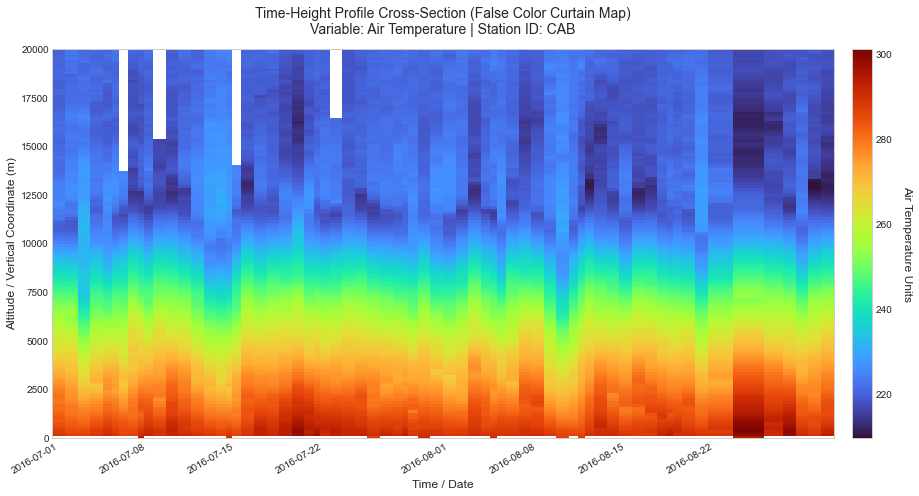

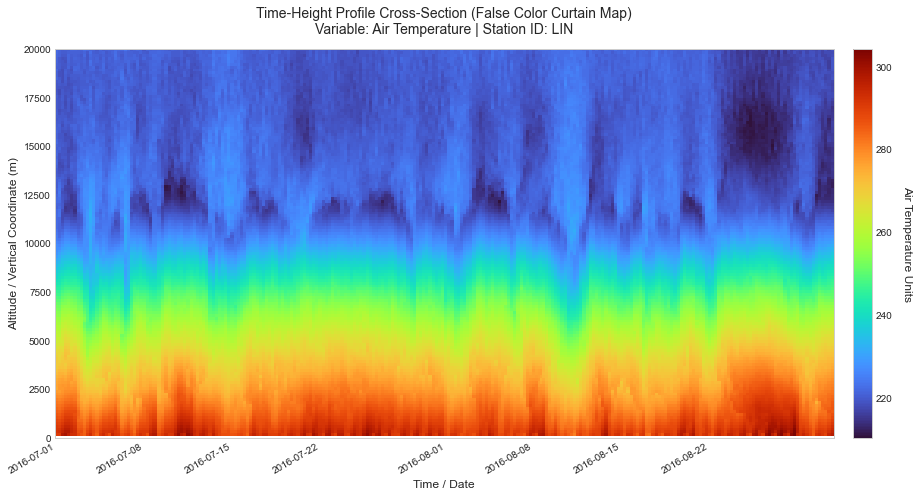

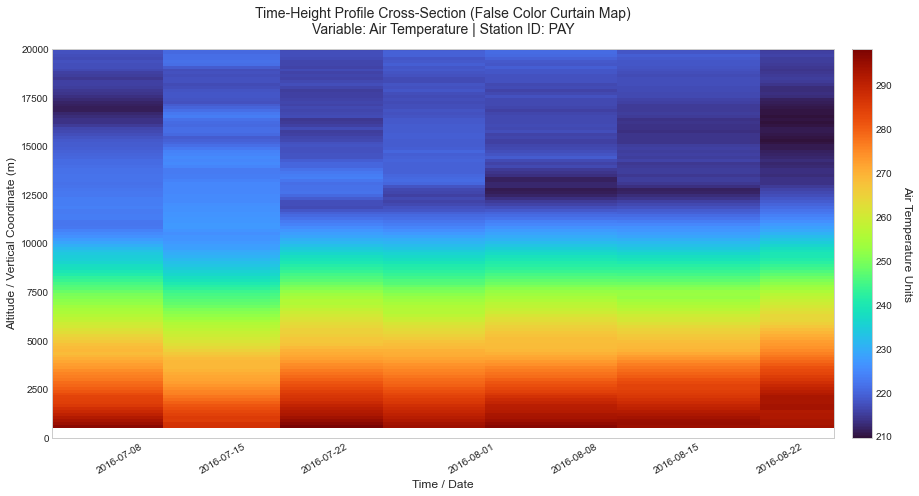

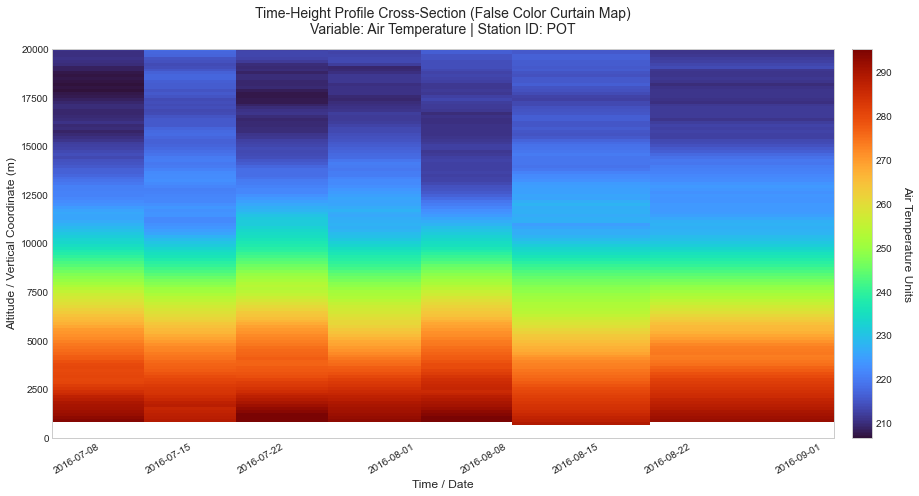

In [21]:
# =============================================================================
# EXECUTION & PLOTTING
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd

target_var_code = 126  # Air Temperature
colormap_choice = 'turbo'
time_window = None

grid_dz = 150.0  # Vertical resolution step (m)
maximum_alt = 20000.0  # Maximum altitude ceiling (m)

# 1. Extract separate Time-Height matrices per station
matrices_per_station = generate_time_height_matrix(
    dataset=ds,
    var_code=target_var_code,
    mode='BOUNDING_BOX',
    bbox=bounding_box,
    time_range=time_window,
    dz=grid_dz,
    z_max=maximum_alt,
)

print(
    f'Stations with extracted Time-Height matrix: {list(matrices_per_station.keys())}'
)

# 2. Generate an individual Curtain Plot cross-section for each station
for st_id, (timestamps, z_levels, Z_data) in matrices_per_station.items():
    fig, ax = plt.subplots(figsize=(14, 7))

    time_mesh = pd.to_datetime(timestamps)

    mesh = ax.pcolormesh(
        time_mesh, z_levels, Z_data, shading='auto', cmap=colormap_choice
    )

    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(
        f'{get_var_name_en(target_var_code)} Units',
        rotation=270,
        labelpad=20,
        fontsize=12,
    )

    ax.set_ylabel('Altitude / Vertical Coordinate (m)', fontsize=12)
    ax.set_xlabel('Time / Date', fontsize=12)
    ax.set_ylim(0, maximum_alt)

    ax.set_title(
        f'Time-Height Profile Cross-Section (False Color Curtain Map)\n'
        f'Variable: {get_var_name_en(target_var_code)} | Station ID: {st_id}',
        fontsize=14,
        pad=15,
    )

    fig.autofmt_xdate()
    ax.grid(True, linestyle=':', alpha=0.5, color='white')

    plt.tight_layout()
    plt.show()

### 4. Atmospheric layer distribution analysis

This section investigates the statistical behavior and variability of key atmospheric parameters within a target vertical slice of the atmosphere (e.g., between $5\,000\text{ m}$ and $6\,000\text{ m}$). Unlike full vertical profiles that examine continuous changes across all altitudes, this layer-based analysis isolates a specific altitude boundary to evaluate how observations are distributed within that layer. Key Objectives
- Subsets un-binned raw observation values falling strictly inside a defined altitude interval $[z_{\text{min}}, z_{\text{max}}]$.
- Supports analyzing either a single monitoring site ('STATION') or evaluating multiple stations independently within a spatial region ('BOUNDING_BOX').
- Computes core statistical indicators (mean, median, and standard deviation) and generates a $2\times 2$ histogram grid for selected atmospheric variables (Air Temperature, Relative Humidity, Wind Speed, and Air Pressure) for each station.

### 4.1 Helper Utilities & Variable Lookup

This block handles variable name mapping for atmospheric parameters and dynamically resolves header variable names in xarray.Dataset objects.

In [24]:
# =============================================================================
# Helper Utilities and Variable Lookup
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# CDM-OBS Variable Code mapping to English standard descriptions
VAR_NAMES_EN = {
    126: 'Air Temperature',
    138: 'Relative Humidity',
    107: 'Wind Speed',
    142: 'Air Pressure',
}

def get_var_name_en(code: int) -> str:
    """Returns the English descriptive label for a CDM-OBS variable code."""
    return VAR_NAMES_EN.get(code, f'Variable {code}')


def _find_variable_name(dataset: xr.Dataset, candidate_names: list[str]) -> str:
    """Resolves variable names in NetCDF headers via exact and fuzzy case-insensitive matching."""
    for name in candidate_names:
        if name in dataset:
            return name

    for var in dataset.variables:
        var_lower = str(var).lower()
        for cand in candidate_names:
            if cand.lower() in var_lower:
                return str(var)

    raise KeyError(
        f'None of candidate variables {candidate_names} were found in the dataset.'
    )

### 4.2 Layer observations extraction

This block extracts raw, un-binned observations falling strictly within a specified vertical layer $[z_{\text{min}}, z_{\text{max}}]$. Boolean masks are explicitly computed prior to indexing to ensure full compatibility with Dask-backed datasets.

In [25]:
# =============================================================================
# Extract Raw Observations in Altitude Layer
# =============================================================================

from typing import Dict, Optional, Union


def extract_layer_observations(
    dataset: xr.Dataset,
    var_code: int,
    z_min: float,
    z_max: float,
    mode: str = 'STATION',
    station_id: Optional[str] = None,
    report_id: Optional[str] = None,
    bbox: Optional[dict[str, float]] = None,
    time_range: Optional[tuple[str, str]] = None,
) -> Union[np.ndarray, Dict[str, np.ndarray]]:
    """Extracts raw observation values falling strictly within a vertical altitude layer [z_min, z_max].

    Parameters
    ----------
    dataset : xr.Dataset
        The target CDM-OBS dataset.
    var_code : int
        CDM-OBS variable identifier code.
    z_min : float
        Lower altitude boundary in meters.
    z_max : float
        Upper altitude boundary in meters.
    mode : str, optional
        Extraction mode: 'STATION' for a single station, or 'BOUNDING_BOX' for
        all stations within spatial bounds (default is 'STATION').
    station_id : str, optional
        Target station identifier when mode='STATION'.
    report_id : str, optional
        Specific sounding/report identifier (optional).
    bbox : dict, optional
        Spatial bounds {'lat_min', 'lat_max', 'lon_min', 'lon_max'} when mode='BOUNDING_BOX'.
    time_range : tuple of str, optional
        Temporal bounds formatted as ('YYYY-MM-DD', 'YYYY-MM-DD').

    Returns
    -------
    np.ndarray or dict
        - Mode 'STATION': 1D array of valid clean values.
        - Mode 'BOUNDING_BOX': Dictionary mapping station IDs to 1D arrays of values:
          { station_id_str: np.ndarray, ... }
    """
    lat_var = _find_variable_name(
        dataset, ['latitude', 'lat', 'station_latitude']
    )
    lon_var = _find_variable_name(
        dataset, ['longitude', 'lon', 'station_longitude']
    )
    st_var = _find_variable_name(
        dataset, ['primary_station_identifier', 'station_id', 'platform_id']
    )

    rep_var = None
    for candidate in ['report_id', 'launch_id']:
        if candidate in dataset or any(
            candidate in str(v) for v in dataset.variables
        ):
            try:
                rep_var = _find_variable_name(dataset, [candidate])
                break
            except KeyError:
                continue

    # Base boolean mask for target variable code and vertical altitude bounds
    mask = (
        (dataset['observed_variable'] == var_code)
        & (dataset['z_coordinate'] >= z_min)
        & (dataset['z_coordinate'] <= z_max)
    )

    # Apply temporal filtering if specified
    if time_range is not None:
        t_start, t_end = np.datetime64(time_range[0]), np.datetime64(
            time_range[1]
        )
        time_var = None
        for candidate in [
            'time',
            'report_timestamp',
            'dateTime',
            'time_since_launch',
        ]:
            if candidate in dataset:
                time_var = candidate
                break
        if time_var is not None:
            mask = mask & (dataset[time_var] >= t_start) & (
                dataset[time_var] <= t_end
            )

    # -------------------------------------------------------------------------
    # MODE 1: SINGLE STATION
    # -------------------------------------------------------------------------
    if mode.upper() == 'STATION':
        if station_id is not None:
            mask = mask & (dataset[st_var] == station_id)
        if report_id is not None and rep_var is not None:
            mask = mask & (dataset[rep_var] == report_id)

        # Compute boolean mask explicitly to handle Dask arrays safely
        mask_np = (
            mask.compute().values
            if hasattr(mask, 'compute')
            else np.asarray(mask)
        )
        if not np.any(mask_np):
            return np.array([])

        mask_da = xr.DataArray(mask_np, dims=dataset[st_var].dims)
        ds_sub = dataset.where(mask_da, drop=True)

        vals = ds_sub['observation_value'].values
        return vals[~np.isnan(vals)]

    # -------------------------------------------------------------------------
    # MODE 2: BOUNDING BOX (SEPARATE STATIONS, NO SPATIAL AVERAGING)
    # -------------------------------------------------------------------------
    elif mode.upper() == 'BOUNDING_BOX':
        if bbox is None:
            raise ValueError("Must provide 'bbox' dictionary for BOUNDING_BOX mode.")

        lat_mask = (dataset[lat_var] >= bbox['lat_min']) & (
            dataset[lat_var] <= bbox['lat_max']
        )
        lon_mask = (dataset[lon_var] >= bbox['lon_min']) & (
            dataset[lon_var] <= bbox['lon_max']
        )
        mask = mask & lat_mask & lon_mask

        # Compute mask explicitly
        mask_np = (
            mask.compute().values
            if hasattr(mask, 'compute')
            else np.asarray(mask)
        )
        if not np.any(mask_np):
            return {}

        # Discover unique station IDs inside bounding box
        raw_stations = np.unique(dataset[st_var].values[mask_np])
        stations_in_bbox = [
            st
            for st in raw_stations
            if str(st) != 'nan' and st is not None and str(st) != ''
        ]

        station_results = {}

        for st in stations_in_bbox:
            # Compute station mask explicitly to avoid Dask indexing errors
            st_mask_np = mask_np & (dataset[st_var].values == st)
            if not np.any(st_mask_np):
                continue

            st_mask_da = xr.DataArray(st_mask_np, dims=dataset[st_var].dims)
            ds_sub = dataset.where(st_mask_da, drop=True)

            vals = ds_sub['observation_value'].values
            clean_vals = vals[~np.isnan(vals)]

            if len(clean_vals) > 0:
                st_key = (
                    st.decode('utf-8') if isinstance(st, bytes) else str(st)
                )
                station_results[st_key] = clean_vals

        return station_results

    else:
        raise ValueError(
            f"Unknown mode '{mode}'. Expected 'STATION' or 'BOUNDING_BOX'."
        )

### 4.3 Distribution Plotting

This block extracts variables across the designated layer and renders a 2x2 grid of histograms for each station. It automatically normalizes output structures so it executes uniformly regardless of whether 'STATION' or 'BOUNDING_BOX' mode was selected in Section 2.

Stations found in altitude layer [5000m - 6000m]: ['CAB', 'LIN', 'PAY', 'POT']


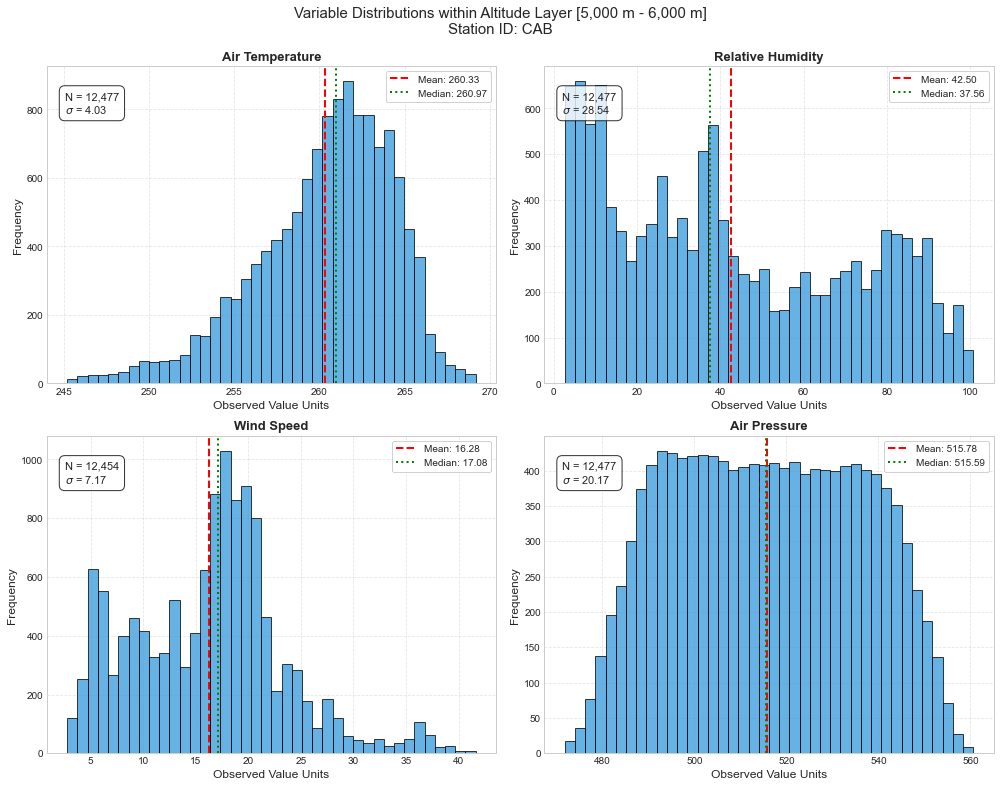

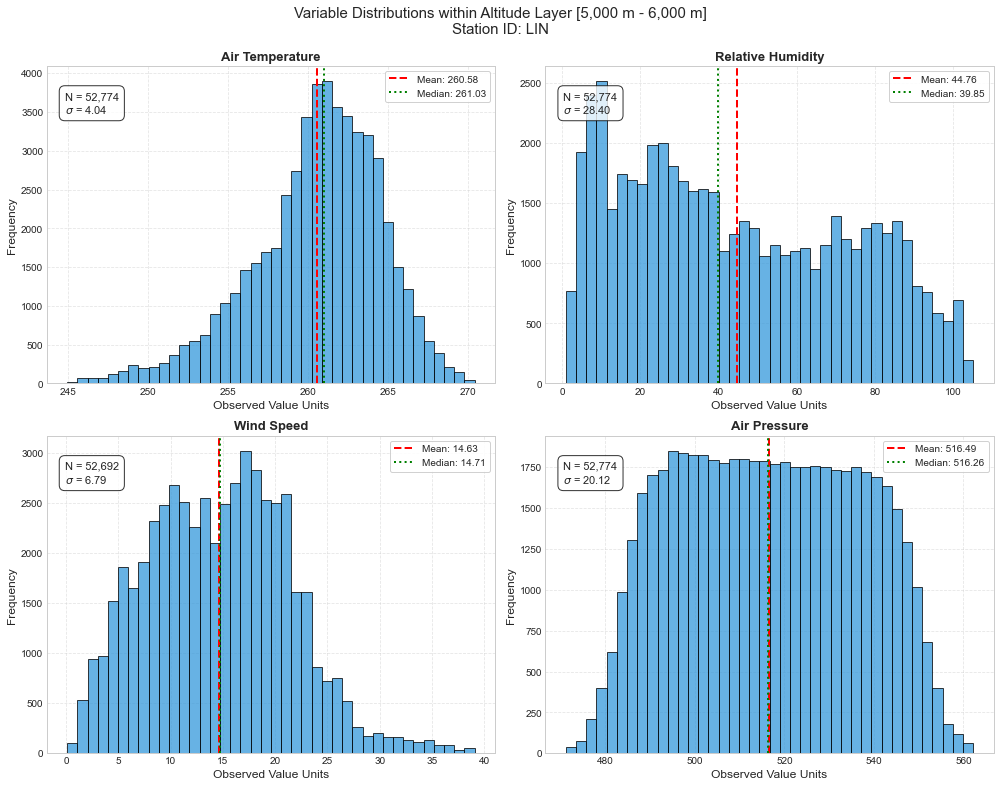

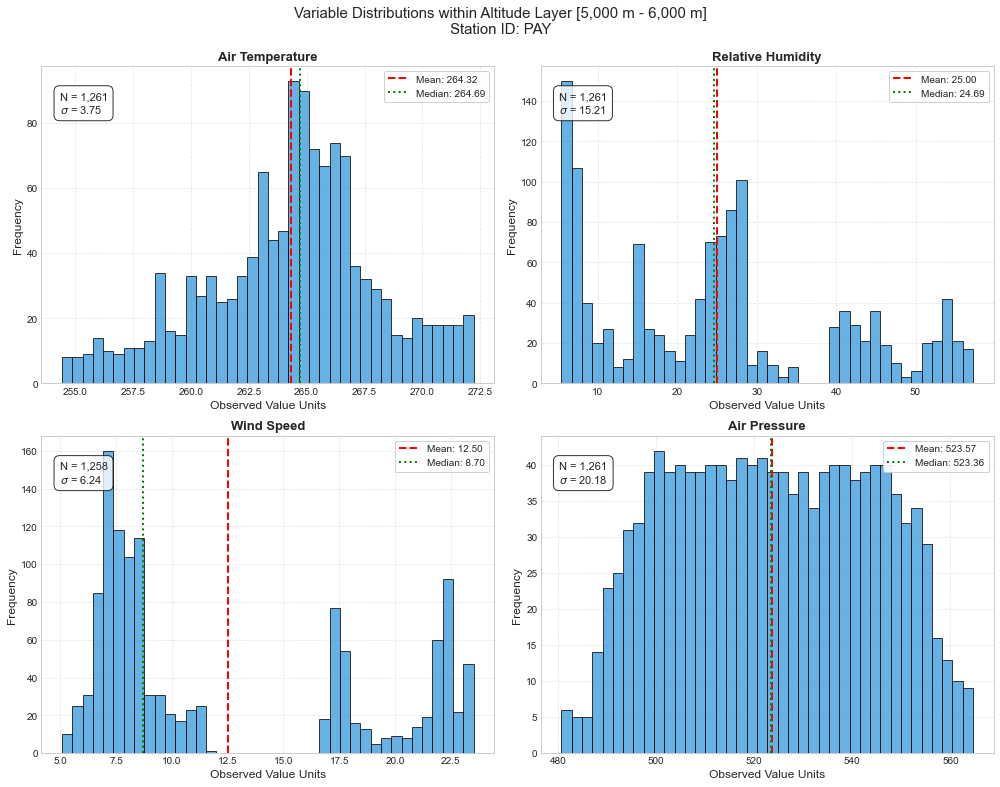

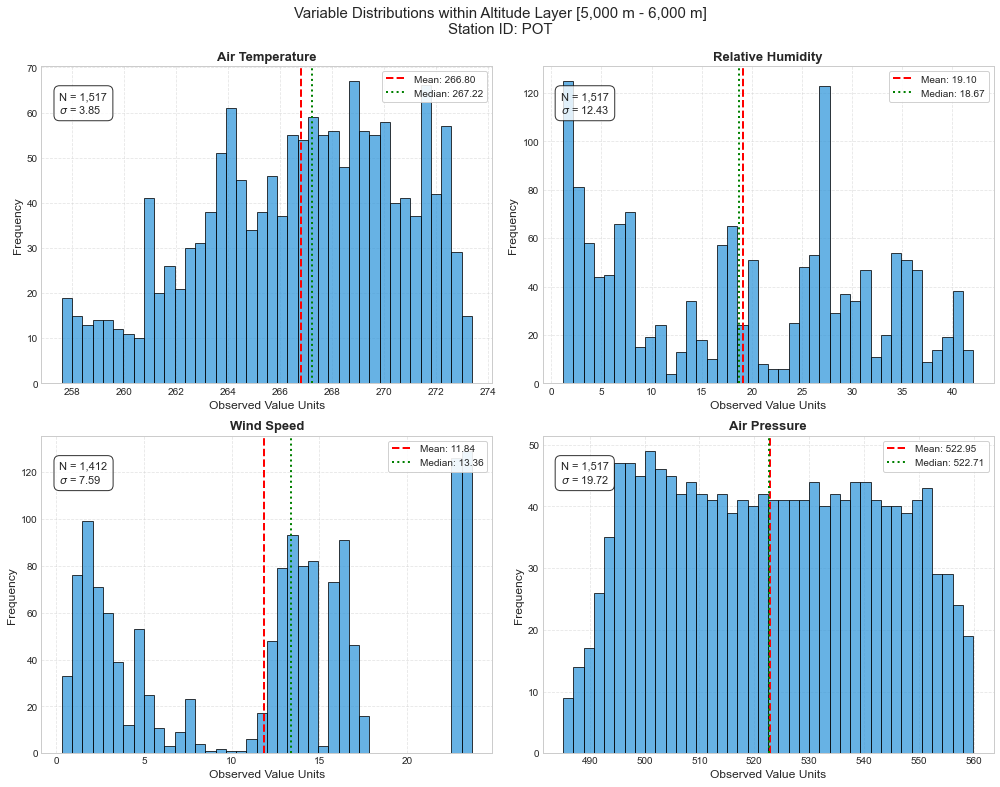

In [26]:
# =============================================================================
# Execution & Layer Distribution Plotting
# =============================================================================

# Altitude layer limits (m)
z_min_layer = 5000.0  # Lower bound (m)
z_max_layer = 6000.0  # Upper bound (m)

# Inherit settings from Section 2 or define defaults
SELECTION_MODE = mode if 'mode' in locals() else 'BOUNDING_BOX'
target_station = station_id if 'station_id' in locals() else None
bounding_box = bbox if 'bbox' in locals() else {'lat_min': 40.0, 'lat_max': 55.0, 'lon_min': 5.0, 'lon_max': 20.0}
time_interval = time_range if 'time_range' in locals() else None

# Selected variables for histogram grid
dist_vars = [126, 138, 107, 142]  # Air Temp, RH, Wind Speed, Air Pressure

# 1. Extract layer observations per variable
layer_data_by_var = {}
for code in dist_vars:
    raw_output = extract_layer_observations(
        dataset=ds,
        var_code=code,
        z_min=z_min_layer,
        z_max=z_max_layer,
        mode=SELECTION_MODE,
        station_id=target_station,
        bbox=bounding_box,
        time_range=time_interval,
    )
    
    # Normalize output format: wrap STATION mode array into a dictionary
    if SELECTION_MODE.upper() == 'STATION':
        st_key = target_station if target_station is not None else 'Selected Station'
        layer_data_by_var[code] = {st_key: raw_output} if len(raw_output) > 0 else {}
    else:
        layer_data_by_var[code] = raw_output

# 2. Identify all unique stations retrieved
all_stations = set()
for code in dist_vars:
    if isinstance(layer_data_by_var[code], dict):
        all_stations.update(layer_data_by_var[code].keys())

print(f'Stations found in altitude layer [{z_min_layer:.0f}m - {z_max_layer:.0f}m]: {sorted(list(all_stations))}')

# 3. Generate 2x2 subplot figure for each station independently
for st_id in sorted(list(all_stations)):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 11))
    axes = axes.flatten()

    for i, code in enumerate(dist_vars):
        vals_in_layer = np.array([])
        if code in layer_data_by_var and st_id in layer_data_by_var[code]:
            vals_in_layer = layer_data_by_var[code][st_id]

        # Plot histogram if valid observations exist
        if len(vals_in_layer) > 0:
            axes[i].hist(
                vals_in_layer,
                bins=40,
                color='#3498db',
                edgecolor='black',
                alpha=0.75,
            )

            # Descriptive statistics
            mean_val = np.mean(vals_in_layer)
            median_val = np.median(vals_in_layer)
            std_val = np.std(vals_in_layer)

            # Mean and Median vertical indicator lines
            axes[i].axvline(
                mean_val,
                color='red',
                linestyle='--',
                linewidth=2,
                label=f'Mean: {mean_val:.2f}',
            )
            axes[i].axvline(
                median_val,
                color='green',
                linestyle=':',
                linewidth=2,
                label=f'Median: {median_val:.2f}',
            )

            axes[i].legend(
                loc='upper right', frameon=True, facecolor='white', framealpha=0.9
            )

            # Summary statistics annotation box
            stats_text = f"N = {len(vals_in_layer):,}\n$\\sigma$ = {std_val:.2f}"
            axes[i].text(
                0.04,
                0.92,
                stats_text,
                transform=axes[i].transAxes,
                fontsize=11,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
            )
        else:
            axes[i].text(
                0.5,
                0.5,
                "No Data in Layer",
                ha='center',
                va='center',
                fontsize=12,
                color='red',
            )

        axes[i].set_title(get_var_name_en(code), fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Observed Value Units')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, linestyle='--', alpha=0.5)

    time_info = (
        f' | Time: {time_interval[0]} to {time_interval[1]}'
        if time_interval
        else ''
    )
    plt.suptitle(
        f'Variable Distributions within Altitude Layer [{z_min_layer:,.0f} m - {z_max_layer:,.0f} m]\n'
        f'Station ID: {st_id}{time_info}',
        fontsize=15,
        y=0.99,
    )

    plt.tight_layout()
    plt.show()

## Take home messages
- GRUAN delivers reference-quality, SI-traceable upper-air profiles (temperature, water vapor, pressure) critical for long-term climate monitoring and satellite calibration/validation (Cal/Val).
- Quality-controlled data with measurement uncertainty estimates are available via the CDS, adhering to strict scientific data policies and WMO guidelines.
- Efficient analysis of high-resolution profiles leverages NetCDF standards (via xarray or netCDF4 in Python) to seamlessly handle multidimensional observation variables and uncertainty bounds.
- Binning soundings onto a uniform height grid ($dz$) enables robust statistical aggregation. This highlights mean vertical gradients (e.g., temperature lapse rates, moisture decay) while quantifying observational variability ($\pm 1\sigma$);
- Isolating specific altitude intervals ($[z_{\text{min}}, z_{\text{max}}]$) provides localized statistical diagnostics (mean, median, standard deviation). This is interesting for evaluating specific atmospheric regimes, such as the planetary boundary layer or jet-stream levels.Continuous Dynamic Tracking;
- 2D Time-Height curtain plots reveal the evolution of atmospheric structure over time, making it easy to identify dynamic events such as diurnal boundary layer growth, frontal passages, thermal inversions, or any longer term tendecy.
- Explicit array computation and masking ensure full compatibility with Dask-backed datasets, preventing lazy-evaluation indexing issues when processing large-scale NetCDF observation files.

## References
[1] Bodeker, G. E., Bojinski, S., Cimini, D., Dirksen, R. J., Haeffelin, M., Hannigan, J. W., Hurst, D. F., Leblanc, T., Madonna, F., Maturilli, M., Mikalsen, A. C., Philipona, R., Reale, T., Seidel, D. J., Tan, D. G. H., Thorne, P. W., Vömel, H., & Wang, J. (2016). Reference Upper-Air Observations for Climate: From Concept to Reality. Bulletin of the American Meteorological Society, 97(1), 123–135. https://doi.org/10.1175/BAMS-D-14-00072.1

[2] Dirksen, R. J., Sommer, M., Immler, F. J., Hurst, D. F., Kivi, R., & Vömel, H. (2014). Reference quality upper-air measurements: GRUAN data processing for the Vaisala RS92 radiosonde. Atmospheric Measurement Techniques, 7(12), 4463–4490. https://doi.org/10.5194/amt-7-4463-2014

[3] Sommer, M., von Rohden, C., & Simeonov, T. (2023). GRUAN characterisation and data processing of the Vaisala RS41 radiosonde. GRUAN Technical Document 8 (GRUAN-TD-8), v1.0.0.

[4] Hoshino, S., Sugidachi, T., Shimizu, K., Kobayashi, E., Fujiwara, M., & Iwabuchi, M. (2022). Comparison of GRUAN data products for Meisei iMS-100 and Vaisala RS92 radiosondes at Tateno, Japan. Atmospheric Measurement Techniques, 15(19), 5917–5935. https://doi.org/10.5194/amt-15-5917-2022

[5] Kobayashi, E., Hoshino, S., Iwabuchi, M., Sugidachi, T., Shimizu, K., & Fujiwara, M. (2019). Comparison of the GRUAN data products for Meisei RS-11G and Vaisala RS92-SGP radiosondes at Tateno (36.06° N, 140.13° E), Japan. Atmospheric Measurement Techniques, 12(6), 3039–3065. https://doi.org/10.5194/amt-12-3039-2019

## License
Here is a brief summary of the GRUAN data policy:

Citing and acknowledgements: ysers of GRUAN data in publications must acknowledge GRUAN, reference the specific sites used alongside their respective DOIs, and send a copy of the final paper to the Lead Centre.

Co-authorship: while not required for standard radiosonde data, co-authorship is highly encouraged. For non-radiosonde data or data processed from non-GRUAN sites, co-authorship should be offered to the relevant GDP developers and instrument specialists.

For complete details and specific guidelines, please consult the official GRUAN Data License information in the CDS or on teh GRUAN website.